# MWE: choosing the regulariser and its weight with L-curves

A regularised image fit minimises ½χ² + w R(image), and the weight w decides the balance. Too small, and the image fits the noise; too large, and it is smoothed into whatever the regulariser prefers. `drpangloss.imaging.l_curve` fits a problem over a range of weights, from strong to weak, each starting from the previous solution, and returns χ² and the unweighted penalty R of every fit. Plotted against each other on log axes, they trace an "L", as in Charles et al. (2025, arXiv:2510.10924). Two automatic readings are provided: `corner()`, the point of maximum curvature, and `discrepancy(target)`, the weight at which χ² per data point rises to a target just above one (Morozov's discrepancy principle).

This notebook draws L-curves for maximum entropy (MEM), total squared variation (TSV) and total variation (TV) on the simulated ring of the previous MWE, and compares the images they select. You should come away knowing how to choose a weight, and why you should still look at the images either side of it.

In [1]:
import sys
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)
sys.path.insert(0, str(root / "src"))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from drpangloss.amigo import simulated_disco_record
from drpangloss.fitting import Problem
from drpangloss.imaging import TSV, TV, MaxEntropy, image_priors, l_curve
from drpangloss.models import GaussianDisk, Image, PointSource, System
from drpangloss.oidata import OIData
from drpangloss.plotting import plot_model
from drpangloss.scenes import ring

template = OIData(
    simulated_disco_record(wavelength_m=4.8e-6, rotation_deg=-6.9)
)
npix, scale = 32, 10.0
truth_image = ring(
    npix,
    scale,
    80.0,
    12.0,
    inc_deg=50.0,
    pa_deg=30.0,
    asymmetry=0.5,
    asymmetry_pa_deg=90.0,
)
truth = System(
    star=PointSource(), env=Image.from_brightness(truth_image, scale, flux=0.1)
)
data = template.with_model(truth, key=jax.random.PRNGKey(0))
start = System(
    star=PointSource(),
    env=Image.from_model(GaussianDisk(60.0), npix, scale, flux=0.1),
)
target = 1.0 + 2.0 * jnp.sqrt(
    2.0 / data.vis.size
)  # two standard deviations of chi2/N above 1
print(f"{data.vis.size} data points; discrepancy target chi2/N = {target:.3f}")

W0930 23:27:53.180064 9955512 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


314 data points; discrepancy target chi2/N = 1.160


## Sweeping the weights

Each regulariser has its own natural scale, so each gets its own range of weights, 13 values over four to five decades. MEM and TV are fitted with L-BFGS and TSV with Levenberg–Marquardt. The whole sweep takes about a minute. A few of the fits at the weakest weights hit their step limit, which `fit` reports as a warning; their images are still shown.

In [2]:
settings = {
    "MEM": (MaxEntropy, "lbfgs", jnp.logspace(0, 4, 13)),
    "TSV": (TSV, "lm", jnp.logspace(2, 6, 13)),
    "TV": (TV, "lbfgs", jnp.logspace(-1, 4, 13)),
}
curves = {}
for name, (regulariser, method, weights) in tqdm(settings.items()):
    make = lambda w, R=regulariser: Problem(
        start, data, image_priors(start), [R(w, path="env")]
    )
    curves[name] = l_curve(make, weights, method=method)
chosen = {
    name: (c.corner(), c.discrepancy(target)) for name, c in curves.items()
}
for name, (corner, disc) in chosen.items():
    print(
        f"{name}: corner at w = {corner:.3g}, discrepancy at w = {disc:.3g}"
        if disc
        else f"{name}: corner at w = {corner:.3g}, no discrepancy crossing"
    )

  0%|          | 0/3 [00:00<?, ?it/s]

/Users/benpope/code/drpangloss/src/drpangloss/imaging.py:363: RuntimeWarning: fit(method='lm') did not converge in 1000 steps.
  result = fit(problem, **fit_options)


/Users/benpope/code/drpangloss/src/drpangloss/imaging.py:363: RuntimeWarning: fit(method='lbfgs') did not converge in 20000 steps.
  result = fit(problem, **fit_options)


MEM: corner at w = 100, discrepancy at w = 697
TSV: corner at w = 1e+04, discrepancy at w = 7.78e+04
TV: corner at w = 82.5, discrepancy at w = 756


## The L-curves

Moving along each curve from right to left, the weight falls, χ² falls and the penalty rises. The corner (circle) is where the curve turns from mostly buying χ² to mostly buying penalty, and the discrepancy weight (square) is where χ² per point reaches the target. The corner is sensitive to how densely and evenly the sweep samples the curve, which is one reason to plot it rather than trust it blindly.

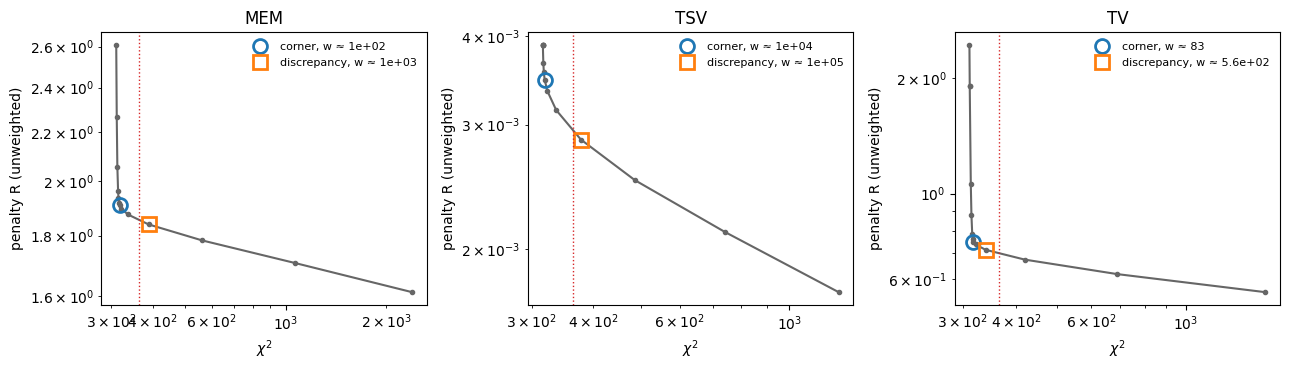

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (name, c) in zip(axes, curves.items()):
    ax.loglog(c.chi2, c.penalty, "-o", ms=3, color="0.4")
    for w, marker, label in [
        (chosen[name][0], "o", "corner"),
        (chosen[name][1], "s", "discrepancy"),
    ]:
        if w is None:
            continue
        i = int(jnp.argmin(jnp.abs(jnp.log(c.weights) - jnp.log(w))))
        ax.loglog(
            c.chi2[i],
            c.penalty[i],
            marker,
            ms=10,
            mfc="none",
            mew=2,
            label=f"{label}, w ≈ {c.weights[i]:.2g}",
        )
    ax.axvline(target * data.vis.size, color="C3", ls=":", lw=1)
    ax.set(xlabel=r"$\chi^2$", ylabel="penalty R (unweighted)", title=name)
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## The images the criteria select

For each regulariser, the image at its discrepancy weight is shown next to the truth, with its normalised cross-correlation (1 is a perfect match) in the title. MEM does best on this smooth ring; TSV blurs it slightly, and TV, which favours flat regions with sharp edges, makes it blockier.

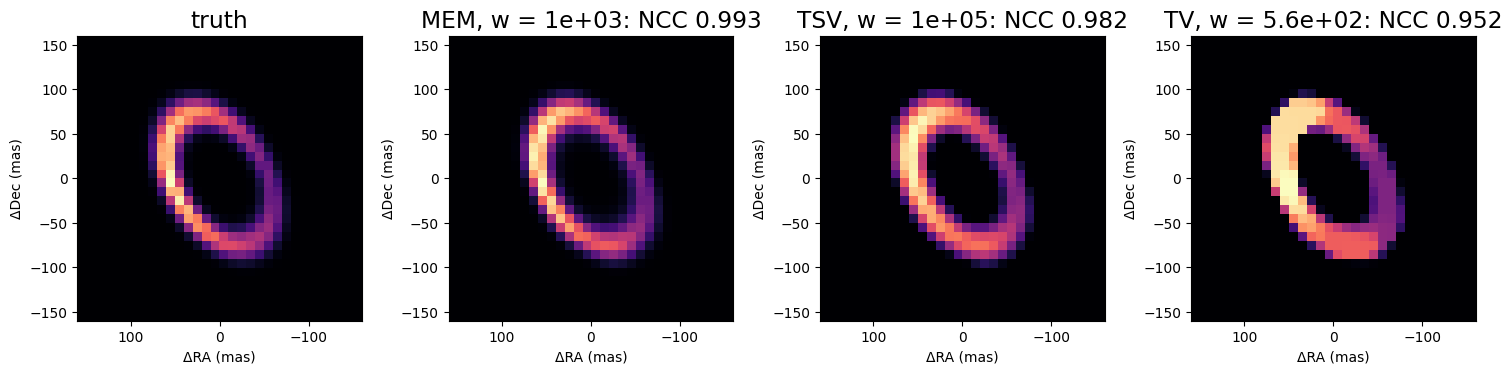

In [4]:
def ncc(a, b):
    a, b = a - a.mean(), b - b.mean()
    return float(jnp.sum(a * b) / jnp.sqrt(jnp.sum(a * a) * jnp.sum(b * b)))


fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
plot_model(
    truth.env, fov_mas=npix * scale, npix=npix, ax=axes[0], title="truth"
)
for ax, (name, c) in zip(axes[1:], curves.items()):
    w = chosen[name][1] or chosen[name][0]
    i = int(jnp.argmin(jnp.abs(jnp.log(c.weights) - jnp.log(w))))
    image = c.results[i].model.env
    plot_model(
        image,
        fov_mas=npix * scale,
        npix=npix,
        ax=ax,
        title=f"{name}, w = {c.weights[i]:.2g}: NCC {ncc(image.brightness, truth_image):.3f}",
    )
plt.tight_layout()
plt.show()

## Under- and over-regularisation

The MEM images along its sweep show what the weight does. At the strongest weight the ring is blurred towards the flat default image and χ² is far too high. Between about 10² and 10³ the image barely changes and χ² per point is close to one, so any weight in this broad range gives essentially the same answer, which is the usual situation (Charles et al. note the same). At the weakest weights the noise takes over and the image breaks up into speckles while χ² hardly improves.

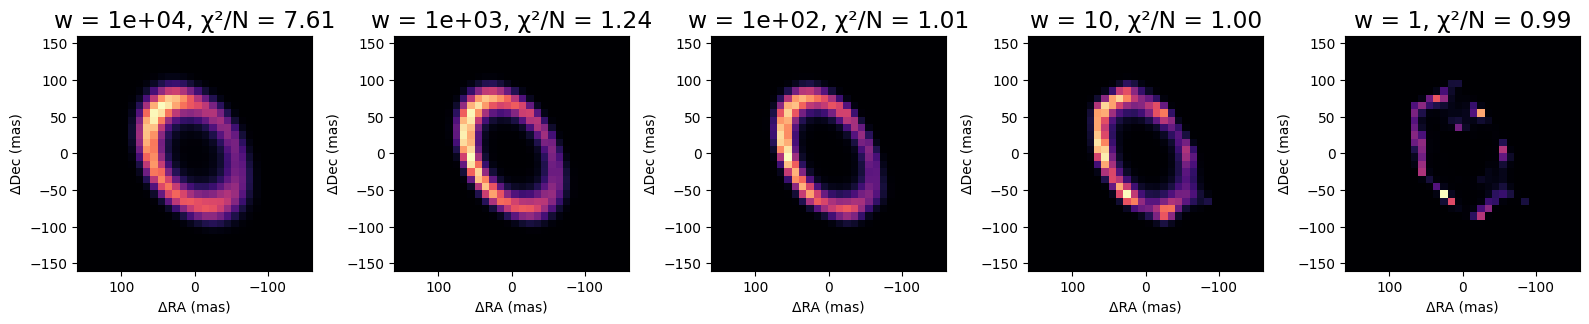

In [5]:
c = curves["MEM"]
picks = [0, 3, 6, 9, 12]
fig, axes = plt.subplots(1, len(picks), figsize=(16, 3.4))
for ax, i in zip(axes, picks):
    image = c.results[i].model.env
    plot_model(
        image,
        fov_mas=npix * scale,
        npix=npix,
        ax=ax,
        title=f"w = {c.weights[i]:.2g}, χ²/N = {c.chi2_red[i]:.2f}",
    )
plt.tight_layout()
plt.show()

## Summary

`l_curve` sweeps a regulariser's weight with warm starts, and its `corner` and `discrepancy` methods suggest a weight from the same sweep at no extra cost. For this ring both land in the broad range of good weights, and MEM gives the best image. Plot the curve and look at the images either side of the chosen weight before trusting it; `design/regulariser_weight_selection.md` discusses more sophisticated criteria (cross-validation, generalised cross-validation, Bayesian evidence), which are deferred to the Gaussian-process stage.